# 3. ColBERT Embeddings: Late Interaction

In this notebook, we'll implement ColBERT (Contextualized Late Interaction over BERT) - the game-changing approach that uses **token-level embeddings** instead of compressing entire documents into single vectors.

## Why ColBERT Changes Everything

Traditional dense retrieval (notebook 2) compresses a 50-word restaurant review into a single 384-dimensional vector. That's like trying to summarize a movie with one emoji! 🎬→😀

ColBERT keeps **every token's embedding** and uses **MaxSim** to find the best token-to-token matches. This preserves nuanced details that get lost in traditional RAG.

## Key Concepts
- **Late Interaction**: Embeddings interact at search time, not indexing time
- **Token-level Matching**: Every word gets its own vector
- **MaxSim Operation**: For each query token, find its best match across all document tokens
- **Multi-vector Storage**: LanceDB stores multiple embeddings per document

In [135]:
# Setup environment
import sys
sys.path.append("../..")
from setup import *

# Verify we're in the right place
print(f"📂 Working in: {os.getcwd()}")
print(f"🎯 Project root: {os.getenv('PROJECT_ROOT')}")
print(f"📊 Data directory: {os.getenv('DATA_DIR')}")

📂 Working in: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
🎯 Project root: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
📊 Data directory: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data


## Show Image Function

In [2]:
from IPython.display import Image, display

def show_image(image_filename="ColBERT/explainibility.png", notebook_dir_env="NOTEBOOKS_DIR"):
    """
    Displays an image from the ColBERT explainability directory.
    
    Args:
        image_filename (str): Relative path to the image file within the notebook directory.
        notebook_dir_env (str): Name of the environment variable containing the notebook directory path.
    """
    import os
    notebook_dir = os.getenv(notebook_dir_env)
    if notebook_dir is None:
        raise ValueError(f"Environment variable '{notebook_dir_env}' is not set.")
    image_path = os.path.join(notebook_dir, image_filename)
    print("Image path:", image_path)
    display(Image(filename=image_path))


## Install and Import ColBERT Dependencies

We'll use **PyLate** - a modern Python library for ColBERT implementation that's actively maintained and optimized.

In [136]:
# Install PyLate if not already installed
try:
    import pylate
    print("✅ PyLate already installed")
except ImportError:
    print("📦 Installing PyLate...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pylate"])
    import pylate
    print("✅ PyLate installed successfully")

# Import required libraries
import torch
from pylate import models, retrieve
import lancedb
from pathlib import Path
import json
from typing import List, Dict, Tuple
import time

print(f"🔧 PyLate version: {pylate.__version__ if hasattr(pylate, '__version__') else 'unknown'}")
print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🖥️  Using device: {get_device()}")

✅ PyLate already installed
🔧 PyLate version: unknown
🔧 PyTorch version: 2.2.2
🖥️  Using device: mps


## Late Interaction Explanation

Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/Colbert/colbert.png


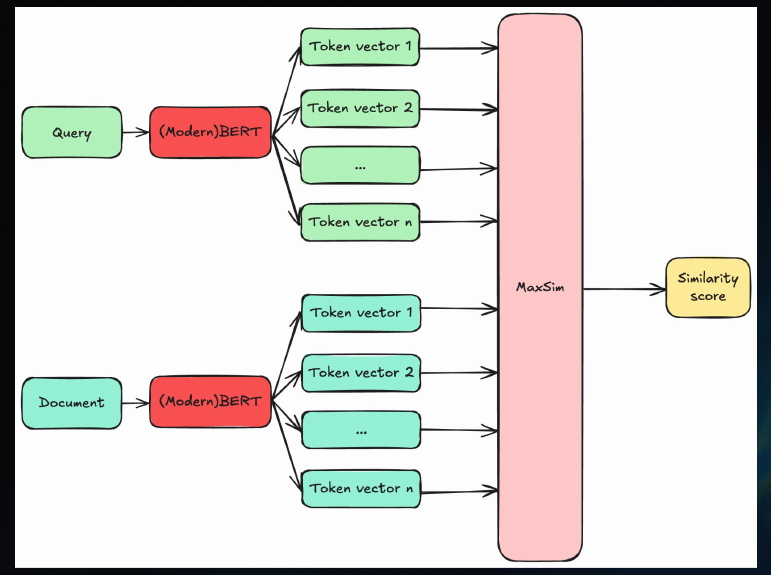

In [3]:
show_image("Colbert/colbert.png")

## Load ColBERT Model

We'll use the same base model (all-MiniLM-L6-v2) but with ColBERT's token-level approach instead of sentence-level compression.

In [137]:
# Load ColBERT model
model_name = os.getenv('COLBERT_MODEL_NAME', 'sentence-transformers/all-MiniLM-L6-v2')
device = get_device()

print(f"🤖 Loading ColBERT model: {model_name}")
print(f"🖥️  Device: {device}")

start_time = time.time()

# Initialize ColBERT model with PyLate
colbert_model = models.ColBERT(
    model_name_or_path=model_name,
    device=device,
    query_length=16
)

load_time = time.time() - start_time
print(f"✅ ColBERT model loaded in {load_time:.2f} seconds")
print(f"📏 Embedding dimension: {colbert_model.get_sentence_embedding_dimension()}")
print(f"📚 Max sequence length: {colbert_model.get_max_seq_length()}")

🤖 Loading ColBERT model: sentence-transformers/all-MiniLM-L6-v2
🖥️  Device: mps


The checkpoint does not contain a linear projection layer. Adding one with output dimensions (384, 128).
Created a PyLate model from base encoder.
The tokenizer does not support resizing the token embeddings, the prefixes token have not been added to vocabulary.


✅ ColBERT model loaded in 4.16 seconds
📏 Embedding dimension: 128
📚 Max sequence length: 256


## Load Restaurant Data

Load the same restaurant reviews we used in the dense embedding notebook.

In [138]:
# Load restaurant reviews
reviews_path = os.getenv('RESTAURANT_REVIEWS_CSV')
print(f"📖 Loading reviews from: {reviews_path}")

df = pd.read_csv(reviews_path)
print(f"📊 Loaded {len(df)} reviews")
print(f"📋 Columns: {list(df.columns)}")

# Display sample review to understand the data
print("\n🍝 Sample review:")
sample = df.iloc[0]
print(f"Restaurant: {sample['restaurant']}")
print(f"Review: {sample['review'][:200]}...")
print(f"Rating: {sample['rating']}/5")

# Prepare documents for embedding (same preprocessing as dense notebook)
# Combine restaurant name with review for consistent schema
documents = [f"{row['restaurant']}: {row['review']}" for _, row in df.iterrows()]
print(f"\n📄 {len(documents)} documents ready for ColBERT embedding")
print(f"📝 Sample document: {documents[0][:100]}...")

📖 Loading reviews from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data/restaurant_reviews.csv
📊 Loaded 12 reviews
📋 Columns: ['id', 'restaurant', 'review', 'reviewer', 'rating']

🍝 Sample review:
Restaurant: Mario's Bistro
Review: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfriend and we sat on their adorable outdoor patio with all the string lights - so romantic! The pasta was absolutely i...
Rating: 5/5

📄 12 documents ready for ColBERT embedding
📝 Sample document: Mario's Bistro: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfr...


## Create ColBERT Embeddings

This is where the magic happens! Unlike dense embeddings that create one vector per document, ColBERT creates **multiple vectors per document** - one for each token.

### Token-Level Analysis
Let's first examine how ColBERT tokenizes and embeds a single review to understand the difference.

In [139]:
# Analyze a single review to understand token-level embeddings
sample_document = documents[0]  # Mario's Bistro combined document
print(f"🔍 Analyzing sample document: {sample_document[:100]}...")

# Create embeddings for the sample document
print("\n⚡ Creating ColBERT embeddings...")
sample_embeddings = colbert_model.encode([sample_document], is_query=False)

# Extract embeddings for analysis
sample_tensor = sample_embeddings[0]  # First (and only) document
num_tokens, embedding_dim = sample_tensor.shape

print(f"📏 Document length: {len(sample_document.split())} words")
print(f"🎯 Number of tokens: {num_tokens}")
print(f"📐 Embedding dimension: {embedding_dim}")
print(f"💾 Total embeddings: {num_tokens * embedding_dim} floats")

# Compare with dense approach
dense_size = 384  # from notebook 2
colbert_size = num_tokens * embedding_dim
size_ratio = colbert_size / dense_size

print(f"\n📊 Size Comparison:")
print(f"   Dense embedding: {dense_size} floats")
print(f"   ColBERT embeddings: {colbert_size} floats")
print(f"   ColBERT is {size_ratio:.1f}x larger but {size_ratio:.1f}x more detailed!")

🔍 Analyzing sample document: Mario's Bistro: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfr...

⚡ Creating ColBERT embeddings...
📏 Document length: 84 words
🎯 Number of tokens: 91
📐 Embedding dimension: 128
💾 Total embeddings: 11648 floats

📊 Size Comparison:
   Dense embedding: 384 floats
   ColBERT embeddings: 11648 floats
   ColBERT is 30.3x larger but 30.3x more detailed!


## Embed All Restaurant Reviews

Now let's create ColBERT embeddings for all restaurant reviews. Each review will have multiple token-level embeddings.

In [140]:
# Create ColBERT embeddings for all reviews
print(f"🚀 Creating ColBERT embeddings for {len(documents)} reviews...")
start_time = time.time()

# Encode all documents
all_embeddings = colbert_model.encode(documents, is_query=False)

embedding_time = time.time() - start_time
print(f"✅ Embedding completed in {embedding_time:.2f} seconds")
print(f"⚡ Average: {embedding_time/len(documents):.3f} seconds per review")

# Analyze the embedding} structure
total_tokens = sum(emb.shape[0] for emb in all_embeddings)
avg_tokens = total_tokens / len(all_embeddings)
min_tokens = min(emb.shape[0] for emb in all_embeddings)
max_tokens = max(emb.shape[0] for emb in all_embeddings)

print(f"\n📊 Embedding Statistics:")
print(f"   Total tokens across all reviews: {total_tokens:,}")
print(f"   Average tokens per review: {avg_tokens:.1f}")
print(f"   Min tokens in a review: {min_tokens}")
print(f"   Max tokens in a review: {max_tokens}")
print(f"   Embedding dimension: {all_embeddings[0].shape[1]}")

# Memory usage estimation
total_floats = sum(emb.shape[0] * emb.shape[1] for emb in all_embeddings)
memory_mb = (total_floats * 4) / (1024 * 1024)  # 4 bytes per float32
print(f"   Estimated memory: {memory_mb:.1f} MB")

🚀 Creating ColBERT embeddings for 12 reviews...
✅ Embedding completed in 0.14 seconds
⚡ Average: 0.012 seconds per review

📊 Embedding Statistics:
   Total tokens across all reviews: 1,190
   Average tokens per review: 99.2
   Min tokens in a review: 91
   Max tokens in a review: 111
   Embedding dimension: 128
   Estimated memory: 0.6 MB


## Store ColBERT Embeddings in LanceDB

LanceDB supports multi-vector storage natively, making it perfect for ColBERT. We'll store each document's token embeddings as a matrix.

In [141]:
# Setup LanceDB for ColBERT multi-vector storage
vector_store_path = os.getenv('VECTOR_STORE_DIR')
print(f"💾 Setting up LanceDB at: {vector_store_path}")

# Connect to LanceDB
db = lancedb.connect(vector_store_path)
table_name = "colbert_reviews"

# Prepare data for LanceDB with proper multi-vector schema
# Each row contains: metadata + ALL token embeddings for the document
colbert_data = []

for idx, (row, embeddings) in enumerate(zip(df.itertuples(), all_embeddings)):
    # Convert embeddings to list of lists (LanceDB multi-vector format)
    # Handle both tensor and numpy array cases
    if hasattr(embeddings, 'cpu'):
        # PyTorch tensor
        embeddings_list = embeddings.cpu().numpy().tolist()
    else:
        # Already numpy array
        embeddings_list = embeddings.tolist()
    
    record = {
        "id": int(row.id),
        "restaurant": row.restaurant,
        "review": row.review,
        "reviewer": row.reviewer,
        "rating": int(row.rating),
        "combined_text": documents[idx],  # Store the preprocessed text used for embedding
        "token_embeddings": embeddings_list,  # Multi-vector: list of 128-dim vectors
        "num_tokens": len(embeddings_list)
    }
    colbert_data.append(record)

print(f"📦 Prepared {len(colbert_data)} records for multi-vector storage")
print(f"📏 Sample record structure:")
sample_record = colbert_data[0]
print(f"   ID: {sample_record['id']}")
print(f"   Restaurant: {sample_record['restaurant']}")
print(f"   Combined text length: {len(sample_record['combined_text'])} chars")
print(f"   Token embeddings: {sample_record['num_tokens']} vectors of {len(sample_record['token_embeddings'][0])} dimensions")
print(f"   Storage format: List[List[float]] = {type(sample_record['token_embeddings'])}")

💾 Setting up LanceDB at: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/vector_store
📦 Prepared 12 records for multi-vector storage
📏 Sample record structure:
   ID: 1
   Restaurant: Mario's Bistro
   Combined text length: 474 chars
   Token embeddings: 91 vectors of 128 dimensions
   Storage format: List[List[float]] = <class 'list'>


In [142]:
# Create or recreate the ColBERT table with multi-vector support
if table_name in db.table_names():
    print(f"🗑️  Dropping existing table: {table_name}")
    db.drop_table(table_name)

print(f"🏗️  Creating ColBERT table with multi-vector schema: {table_name}")
colbert_table = db.create_table(table_name, colbert_data)

print(f"✅ ColBERT table created successfully!")
print(f"📊 Table info: {len(colbert_table)} records")

# Create index for efficient similarity search
print(f"🔧 Creating multi-vector index...")
try:
    # Create index on token_embeddings with cosine metric
    colbert_table.create_index(
        "token_embeddings",
        index_type="IVF_PQ", 
        metric="cosine",
        num_partitions=8  # Small dataset, use fewer partitions
    )
    print(f"✅ Multi-vector index created successfully!")
except Exception as e:
    print(f"⚠️  Index creation info: {e}")
    print(f"   (Index may not be needed for small datasets)")

# Verify the storage
sample_result = colbert_table.head(1).to_pandas().iloc[0]
stored_embeddings = np.array(sample_result['token_embeddings'])
print(f"\n🔍 Storage verification:")
print(f"   Stored embeddings shape: {stored_embeddings.shape}")
print(f"   Data type: {type(stored_embeddings[0][0])}")
print(f"   Combined text: {sample_result['combined_text'][:60]}...")
print(f"✅ Multi-vector storage verified!")

🗑️  Dropping existing table: colbert_reviews
🏗️  Creating ColBERT table with multi-vector schema: colbert_reviews
✅ ColBERT table created successfully!
📊 Table info: 12 records
🔧 Creating multi-vector index...
⚠️  Index creation info: LanceTable.create_index() got multiple values for argument 'metric'
   (Index may not be needed for small datasets)

🔍 Storage verification:
   Stored embeddings shape: (91,)
   Data type: <class 'numpy.float64'>
   Combined text: Mario's Bistro: OMG this little Italian place is a hidden ge...
✅ Multi-vector storage verified!


## Implement ColBERT Search with MaxSim

Now for the exciting part - implementing ColBERT's **MaxSim** operation! This is what makes ColBERT so powerful.

### MaxSim Explained
For each query token:
1. Find its similarity with ALL document tokens
2. Take the **maximum** similarity (best match)
3. Sum these max similarities across all query tokens

This allows fine-grained matching that dense embeddings can't achieve.

In [143]:
def colbert_search(query: str, table, model, top_k: int = 3) -> List[Dict]:
    """
    Perform ColBERT search using MaxSim operation.
    
    Args:
        query: Search query string
        table: LanceDB table with ColBERT embeddings
        model: ColBERT model for encoding query
        top_k: Number of top results to return
    
    Returns:
        List of search results with scores
    """
    print(f"🔍 ColBERT search: '{query}'")
    
    # Encode query with ColBERT (use same preprocessing as documents)
    query_embeddings = model.encode([query], is_query=True)[0]  # Shape: [query_tokens, dim]
    
    # Convert to tensor if it's a numpy array
    if isinstance(query_embeddings, np.ndarray):
        query_embeddings = torch.tensor(query_embeddings, dtype=torch.float32)
    
    print(f"📝 Query tokens: {query_embeddings.shape[0]}")
    
    # Get all documents from table
    all_docs = table.to_pandas()
    
    results = []
    
    # Compute MaxSim for each document
    for idx, row in all_docs.iterrows():
        # Handle different formats from LanceDB
        doc_embeddings_data = row['token_embeddings']
        
        # Convert to proper tensor format
        if isinstance(doc_embeddings_data, list):
            # Direct list to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data, dtype=torch.float32)
        elif isinstance(doc_embeddings_data, np.ndarray):
            # Convert numpy array (possibly of objects) to list first, then to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data.tolist(), dtype=torch.float32)
        else:
            # Fallback: try to convert via list
            doc_embeddings = torch.tensor(list(doc_embeddings_data), dtype=torch.float32)
        
        # Compute similarity matrix: [query_tokens, doc_tokens]
        similarity_matrix = torch.matmul(query_embeddings, doc_embeddings.T)
        
        # MaxSim: For each query token, find max similarity with any doc token
        max_similarities = torch.max(similarity_matrix, dim=1)[0]  # Shape: [query_tokens]
        
        # Final score: Sum of max similarities
        score = torch.sum(max_similarities).item()
        
        results.append({
            'id': row['id'],
            'restaurant': row['restaurant'],
            'review': row['review'],
            'reviewer': row['reviewer'],
            'rating': row['rating'],
            'score': score,
            'num_tokens': row['num_tokens'],
            'combined_text': row['combined_text']
        })
    
    # Sort by score (descending)
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print(f"✅ Found {len(results)} results, returning top {top_k}")
    return results[:top_k]

def display_colbert_results(results: List[Dict], query: str):
    """
    Display ColBERT search results in a readable format.
    """
    print(f"\n🎯 ColBERT Results for: '{query}'")
    print("=" * 80)
    
    for i, result in enumerate(results, 1):
        print(f"\n{i}. {result['restaurant']} (⭐ {result['rating']}/5)")
        print(f"   Score: {result['score']:.3f} | Tokens: {result['num_tokens']} | Reviewer: {result['reviewer']}")
        print(f"   Review: {result['review'][:200]}{'...' if len(result['review']) > 200 else ''}")
        print("-" * 40)

print("✅ ColBERT search functions defined!")

✅ ColBERT search functions defined!


## Load Dense Models

In [144]:
get_device()

'mps'

In [145]:

# Load Dense Retrieval System
from sentence_transformers import SentenceTransformer
import os
import lancedb
# Load models

dense_db = lancedb.connect(os.getenv('VECTOR_STORE_DIR'))

device_for_dense = 'cpu' if get_device() == 'mps' else get_device()
dense_model = SentenceTransformer(os.getenv('DENSE_MODEL_NAME'),
device=device_for_dense)



# Just open the existing dense table from notebook 2
dense_table = dense_db.open_table("dense_reviews")
print(f"✅ Dense table loaded: {len(dense_table)} records")

✅ Dense table loaded: 12 records


In [146]:
# 6. Basic Dense Search
def search_dense_reviews(query, dense_table, dense_model, top_k=3):
    """
    Search restaurant reviews using dense embeddings (traditional RAG)
    
    Args:
        query (str): Search query
        top_k (int): Number of results to return
    
    Returns:
        pandas.DataFrame: Top matching reviews with similarity scores
    """
    # print(f"🔍 Dense search query: '{query}'")
    
    # Encode query with the same model
    query_start = time.time()
    query_embedding = dense_model.encode(query)
    query_time = time.time() - query_start
    
    # print(f"   ⚡ Query encoding time: {query_time:.3f} seconds")
    
    # Search using LanceDB
    search_start = time.time()
    results = dense_table.search(query_embedding).limit(top_k).to_pandas()
    search_time = time.time() - search_start
    
    # print(f"   🚀 Search time: {search_time:.3f} seconds")
    # print(f"   📊 Found {len(results)} results")
    # Sort results by score descending (higher similarity first)
    if 'score' in results.columns:
        results = results.sort_values('score', ascending=False)
    # Format the results as a list of dicts, matching the example result format
    formatted_results = []
    for _, row in results.iterrows():
        formatted_results.append({
            'id': row['id'],
            'restaurant': row['restaurant'],
            'review': row['review'],
            'reviewer': row['reviewer'],
            'rating': row['rating'],
            'score': row['_distance'] if '_distance' in row else None,
            'num_tokens': row['num_tokens'] if 'num_tokens' in row else None,
            'combined_text': row['text'] if 'text' in row else row.get('combined_text', None)
        })
        # print(f"   🚀 Search time: {search_time:.3f} seconds")
        # print(f"   📊 Found {len(results)} results")
    return formatted_results

print("✅ Dense search function ready!")
print("📦 How it works:")
print("   1. Query → Dense model → Single 384-dim vector")
print("   2. Compare query vector vs all document vectors")
print("   3. Return top-K most similar documents")
print("   4. Uses cosine similarity in 384-dimensional space")

✅ Dense search function ready!
📦 How it works:
   1. Query → Dense model → Single 384-dim vector
   2. Compare query vector vs all document vectors
   3. Return top-K most similar documents
   4. Uses cosine similarity in 384-dimensional space


## Test ColBERT Search

Let's test our ColBERT implementation with the same queries we used in notebook 2 to see how it compares to dense retrieval.

In [147]:
# Test the EXACT same query encoding
test_query = "Italian restaurant"

# 1. Encode query
q_emb = colbert_model.encode([test_query], is_query=True)[0]
print(f"Query shape: {q_emb.shape}")
print(f"Query sum: {q_emb.sum()}")  # This should be identical

# 2. Get Tony's Italian embeddings
tony_row = colbert_table.to_pandas().loc[4]  # Assuming Tony's is row 4
print(f"Tony's restaurant: {tony_row['restaurant']}")

# 3. Manual MaxSim calculation
if isinstance(tony_row['token_embeddings'], list):
    # Direct list to tensor
    doc_embeddings = torch.tensor(tony_row['token_embeddings'], dtype=torch.float32)
elif isinstance(tony_row['token_embeddings'], np.ndarray):
    # Convert numpy array (possibly of objects) to list first, then to tensor
    doc_embeddings = torch.tensor(tony_row['token_embeddings'].tolist(), dtype=torch.float32)
else:
    # Fallback: try to convert via list
    doc_embeddings = torch.tensor(list(tony_row['token_embeddings']), dtype=torch.float32)
q_tensor = torch.tensor(q_emb, dtype=torch.float32) if isinstance(q_emb,
np.ndarray) else q_emb

sim_matrix = torch.matmul(q_tensor, doc_embeddings.T)
max_sims = torch.max(sim_matrix, dim=1)[0]
score = torch.sum(max_sims).item()

print(f"Tony's manual score: {score}")
print(f"Sim matrix shape: {sim_matrix.shape}")
print(f"Max sims: {max_sims[:5]}")  # First 5 max similarities

Query shape: (16, 128)
Query sum: 11.297975540161133
Tony's restaurant: Tony's Italian Kitchen
Tony's manual score: 9.95281982421875
Sim matrix shape: torch.Size([16, 101])
Max sims: tensor([0.8668, 0.8317, 0.9002, 0.6768, 0.6784])


In [148]:
# Test 1: Simple keyword search
query1 = "Italian restaurant"
results1 = colbert_search(query1, colbert_table, colbert_model, top_k=3)
display_colbert_results(results1, query1)

🔍 ColBERT search: 'Italian restaurant'
📝 Query tokens: 16
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'Italian restaurant'

1. Tony's Italian Kitchen (⭐ 3/5)
   Score: 9.953 | Tokens: 101 | Reviewer: James R.
   Review: Wanted to take my wife somewhere nice for our anniversary and Tony's looked perfect online. The food was genuinely excellent - authentic Italian with a great wine list. The ambiance inside is romantic...
----------------------------------------

2. Giuseppe's Pizza (⭐ 4/5)
   Score: 9.385 | Tokens: 101 | Reviewer: Mom of 3
   Review: Brought the whole family here for my son's birthday - 8 people total. This place is perfect for big groups! They have these outdoor picnic tables that fit everyone comfortably. The pizza portions are ...
----------------------------------------

3. Mario's Bistro (⭐ 5/5)
   Score: 9.248 | Tokens: 91 | Reviewer: Sarah M.
   Review: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfriend and we

In [149]:
# Test 2: Work environment query
query2 = "good place to work laptop coding wifi"
results2 = colbert_search(query2, colbert_table, colbert_model, top_k=3)
display_colbert_results(results2, query2)

🔍 ColBERT search: 'good place to work laptop coding wifi'
📝 Query tokens: 16
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'good place to work laptop coding wifi'

1. Code & Coffee (⭐ 5/5)
   Score: 10.661 | Tokens: 93 | Reviewer: DevMike
   Review: As a freelance developer, I'm always hunting for good work spots and Code & Coffee is PERFECT. The wifi is blazing fast (tested at 100+ Mbps), they have dedicated quiet zones with super comfortable ch...
----------------------------------------

2. Starbucks Downtown (⭐ 2/5)
   Score: 10.118 | Tokens: 92 | Reviewer: Lisa K.
   Review: Don't even think about trying to work from this Starbucks location. Yes they have wifi but it's absolutely chaos in there - business meetings, loud phone calls, baristas calling out orders every 2 sec...
----------------------------------------

3. Brew & Bytes (⭐ 1/5)
   Score: 9.984 | Tokens: 101 | Reviewer: FrustratedFreelancer
   Review: What a disappointment! Saw their signs about being 'lap

In [150]:
# Test 4: Family-friendly search
query4 = "family kids children friendly large groups"
results4 = colbert_search(query4, colbert_table, colbert_model, top_k=3)
display_colbert_results(results4, query4)

🔍 ColBERT search: 'family kids children friendly large groups'
📝 Query tokens: 16
✅ Found 12 results, returning top 3

🎯 ColBERT Results for: 'family kids children friendly large groups'

1. Family Garden (⭐ 5/5)
   Score: 10.344 | Tokens: 104 | Reviewer: Busy_Mom
   Review: This place is a godsend for parents! The booths are huge and comfortable, perfect for our family of 5. They have a great kids menu but also tons of healthy options for the adults - I got this amazing ...
----------------------------------------

2. Giuseppe's Pizza (⭐ 4/5)
   Score: 10.164 | Tokens: 101 | Reviewer: Mom of 3
   Review: Brought the whole family here for my son's birthday - 8 people total. This place is perfect for big groups! They have these outdoor picnic tables that fit everyone comfortably. The pizza portions are ...
----------------------------------------

3. Green Tea House (⭐ 4/5)
   Score: 7.833 | Tokens: 102 | Reviewer: ZenSeeker
   Review: If you're looking for a peaceful escape from the ci

## Compare with Simple Questions

In [151]:
import json
def load_json_questions(path:str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [152]:
def compare_both_models(level, idx, question_set):
    question = question_set[level][idx]
    from pprint import pprint
    print("Question:")
    pprint(question)
    dense_result = search_dense_reviews(question['query'], dense_table, dense_model)
    colbert_result = colbert_search(question['query'], colbert_table, colbert_model)    

    print("\nDense Model Result:")
    for idx, item in enumerate(dense_result):
        print({'idx': item.get('id'), 'restaurant': item.get('restaurant')})
    print("\nColBERT Model Result:")
    for idx, item in enumerate(colbert_result):
        print({'idx': item.get('id'), 'restaurant': item.get('restaurant')})

In [153]:
data_dir = os.getenv("DATA_DIR")
# Print the value of the data directory environment variable to verify where data files are expected to be loaded from.
# This helps ensure that the DATA_DIR variable is set correctly and points to the right location.
print("DATA_DIR environment variable is set to:", data_dir)
import os
simple_questions_path = os.path.join(data_dir, "simple_questions.json")
print(f"Loading simple questions from: {simple_questions_path}")
simple_questions = load_json_questions(simple_questions_path)

DATA_DIR environment variable is set to: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data
Loading simple questions from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data/simple_questions.json


In [154]:
compare_both_models(level='simple_queries', question_set=simple_questions, idx=0)

Question:
{'expected_results': [{'reason': 'Explicitly Italian cuisine, authentic pasta',
                       'relevance': 'highly_relevant',
                       'restaurant': "Mario's Bistro",
                       'restaurant_id': 1},
                      {'reason': 'Italian restaurant with authentic food and '
                                 'wine list',
                       'relevance': 'highly_relevant',
                       'restaurant': "Tony's Italian Kitchen",
                       'restaurant_id': 5}],
 'query': 'Italian restaurant',
 'query_id': 1}
🔍 ColBERT search: 'Italian restaurant'
📝 Query tokens: 16
✅ Found 12 results, returning top 3

Dense Model Result:
{'idx': 1, 'restaurant': "Mario's Bistro"}
{'idx': 5, 'restaurant': "Tony's Italian Kitchen"}
{'idx': 7, 'restaurant': "Giuseppe's Pizza"}

ColBERT Model Result:
{'idx': 5, 'restaurant': "Tony's Italian Kitchen"}
{'idx': 7, 'restaurant': "Giuseppe's Pizza"}
{'idx': 1, 'restaurant': "Mario's Bistro"}


In [155]:
compare_both_models(level='simple_queries', question_set=simple_questions, idx=1)

Question:
{'expected_results': [{'reason': 'Sushi restaurant with vegetarian options',
                       'relevance': 'highly_relevant',
                       'restaurant': 'Sakura Sushi',
                       'restaurant_id': 2},
                      {'reason': 'Exclusive sushi experience, omakase style',
                       'relevance': 'highly_relevant',
                       'restaurant': 'Neko Sushi',
                       'restaurant_id': 8}],
 'query': 'sushi place',
 'query_id': 2}
🔍 ColBERT search: 'sushi place'
📝 Query tokens: 16
✅ Found 12 results, returning top 3

Dense Model Result:
{'idx': 8, 'restaurant': 'Neko Sushi'}
{'idx': 2, 'restaurant': 'Sakura Sushi'}
{'idx': 1, 'restaurant': "Mario's Bistro"}

ColBERT Model Result:
{'idx': 2, 'restaurant': 'Sakura Sushi'}
{'idx': 8, 'restaurant': 'Neko Sushi'}
{'idx': 5, 'restaurant': "Tony's Italian Kitchen"}


# More Complex Questions

In [156]:
data_dir = os.getenv("DATA_DIR")
# Print the value of the data directory environment variable to verify where data files are expected to be loaded from.
# This helps ensure that the DATA_DIR variable is set correctly and points to the right location.
print("DATA_DIR environment variable is set to:", data_dir)
import os
complex_questions_path = os.path.join(data_dir, "complex_questions.json")
print(f"Loading simple questions from: {complex_questions_path}")
complex_questions = load_json_questions(complex_questions_path)

DATA_DIR environment variable is set to: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data
Loading simple questions from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data/complex_questions.json


In [157]:
compare_both_models(level='complex_queries', question_set=complex_questions, idx=0)

Question:
{'dense_likely_confusion': ['Starbucks Downtown (wifi but NOT quiet)',
                            'Green Tea House (quiet but NO wifi)'],
 'expected_colbert_winner': {'reason': 'Matches ALL constraints: quiet zones✓ '
                                       'blazing wifi✓ work-friendly✓ under '
                                       '$30✓',
                             'relevance': 'highly_relevant',
                             'restaurant': 'Code & Coffee',
                             'restaurant_id': 3,
                             'supporting_text': 'dedicated quiet zones, '
                                                'blazing fast wifi (100+ '
                                                'Mbps), comfortable chairs, '
                                                'been coming here daily for 3 '
                                                'months'},
 'query': 'quiet wifi laptop work under $30',
 'query_id': 6,
 'query_type': 'multi_constraint',
 'why_dense_st

In [158]:
compare_both_models(level='complex_queries', question_set=complex_questions, idx=2)

Question:
{'dense_likely_confusion': ["Might avoid due to 'expensive' signal",
                            'Cannot understand expensive BUT worth it paradox'],
 'expected_colbert_winner': {'reason': 'Expensive BUT explicitly worth it for '
                                       'special occasions',
                             'relevance': 'highly_relevant',
                             'restaurant': 'Le Bernardin SF',
                             'restaurant_id': 4,
                             'supporting_text': 'EXPENSIVE $220 per person BUT '
                                                'worth every single penny, '
                                                'once-in-a-lifetime dining '
                                                'experience'},
 'query': 'expensive but worth every penny special occasion',
 'query_id': 8,
 'query_type': 'contradictory_context',
 'why_dense_struggles': "Conflicting signals: 'expensive' vs 'worth it' - "
                        'dense vecto

In [159]:
compare_both_models(level='complex_queries', question_set=complex_questions, idx=3)

Question:
{'dense_likely_confusion': ['Might return quiet family places',
                            "Cannot handle 'loud atmosphere' as positive"],
 'expected_colbert_winner': {'reason': 'Perfect for large groups✓ kids '
                                       'welcome✓ loud/lively  atmosphere✓',
                             'relevance': 'highly_relevant',
                             'restaurant': "Giuseppe's Pizza",
                             'restaurant_id': 7,
                             'supporting_text': '8 people total, kids were '
                                                'running around andnobody '
                                                'cared, lively and loud in a '
                                                'good way, big groups'},
 'query': 'large family groups kids running around loud atmosphere',
 'query_id': 9,
 'query_type': 'multi_constraint',
 'why_dense_struggles': 'Multiple complex requirements - dense retrieval loses '
                      

## Visualization

Let's analyze the token-level embeddings to understand what ColBERT captures that dense embeddings miss.

Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/ColBERT/explainibility.png


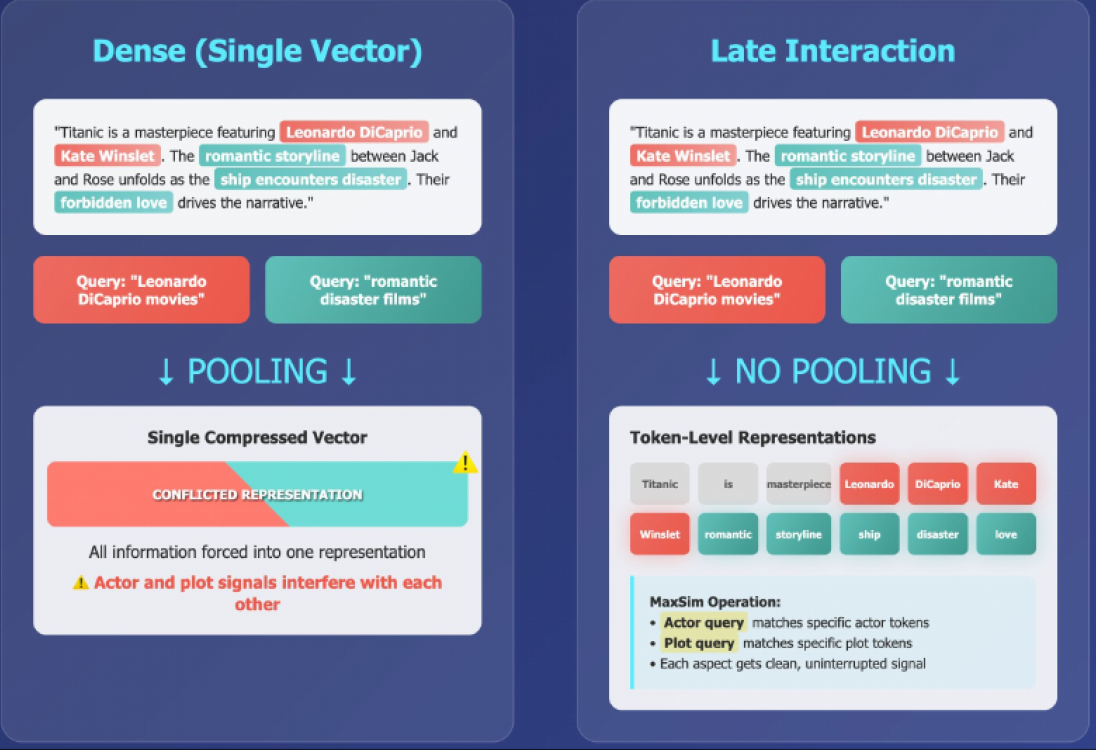

In [4]:

# Example usage:
show_image("ColBERT/explainibility.png")


## Colbert V2

As you saw above, ColBERT v1 achieved fine-grained token-level retrieval, but it came at a cost: the index was large and searching could be slow.

In ColBERT v2, we introduce several clever tricks to dramatically reduce storage and speed up search—without sacrificing retrieval quality. Let's see how these improvements work!
